# British Airways — Customer Booking Prediction
**Forage Data Science Virtual Experience | Task 2**

**Objective:** Build a machine learning model to predict whether a customer will complete a flight booking.  
**Algorithm:** Random Forest Classifier (interpretable, handles class imbalance well, provides feature importance)  
**Dataset:** 50,000 booking records with 13 features + 1 target (`booking_complete`)

---
### Table of Contents
1. [Setup & Data Loading](#1-setup--data-loading)
2. [Exploratory Data Analysis](#2-exploratory-data-analysis)
3. [Feature Engineering](#3-feature-engineering)
4. [Model Training](#4-model-training)
5. [Cross-Validation & Evaluation](#5-cross-validation--evaluation)
6. [Feature Importance](#6-feature-importance)
7. [Findings Summary](#7-findings-summary)

## 1. Setup & Data Loading

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score
)

# Plotting style
BA_NAVY, BA_RED, BA_BLUE = '#001F5B', '#C01820', '#3D85C8'
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'DejaVu Sans'
})
print('Libraries loaded ✓')

Libraries loaded ✓


In [2]:
df = pd.read_csv('customer_booking.csv', encoding='latin1')
print(f'Shape: {df.shape}')
df.head()

Shape: (50000, 14)


,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0


In [3]:
print('=== Basic Info ===')
print(df.dtypes)
print(f'\nMissing values: {df.isnull().sum().sum()}')
print(f'\nTarget distribution:')
print(df['booking_complete'].value_counts())
print(f'\nClass imbalance ratio: {df["booking_complete"].value_counts()[0]/df["booking_complete"].value_counts()[1]:.1f}:1')

=== Basic Info ===
num_passengers             int64
sales_channel             object
trip_type                 object
purchase_lead              int64
length_of_stay             int64
flight_hour                int64
flight_day                object
route                     object
booking_origin            object
wants_extra_baggage        int64
wants_preferred_seat       int64
wants_in_flight_meals      int64
flight_duration          float64
booking_complete           int64
dtype: object

Missing values: 0

Target distribution:
0    42522
1     7478
Name: booking_complete, dtype: int64

Class imbalance ratio: 5.7:1


In [4]:
df.describe()

,num_passengers,purchase_lead,length_of_stay,flight_hour,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
count,50000.000000,50000.000000,50000.00000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.591240,84.940480,23.04456,9.06634,0.668780,0.296960,0.427140,7.277561,0.149560
std,1.020165,90.451378,33.88767,5.41266,0.470657,0.456923,0.494668,1.496863,0.356643
min,1.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,4.670000,0.000000
25%,1.000000,21.000000,5.00000,5.00000,0.000000,0.000000,0.000000,5.620000,0.000000
50%,1.000000,51.000000,17.00000,9.00000,1.000000,0.000000,0.000000,7.570000,0.000000
75%,2.000000,115.000000,28.00000,13.00000,1.000000,1.000000,1.000000,8.830000,0.000000
max,9.000000,867.000000,778.00000,23.00000,1.000000,1.000000,1.000000,9.500000,1.000000


## 2. Exploratory Data Analysis

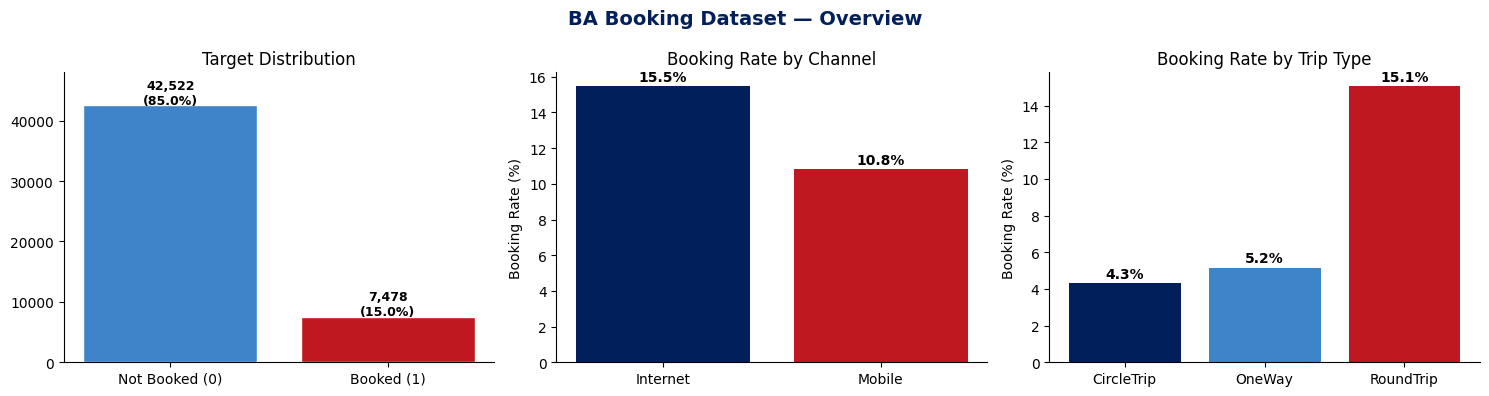

In [8]:
# ── Target class balance ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('BA Booking Dataset — Overview', fontsize=14, fontweight='bold', color=BA_NAVY)

counts = df['booking_complete'].value_counts()
bars = axes[0].bar(['Not Booked (0)', 'Booked (1)'], counts.values,
                   color=[BA_BLUE, BA_RED], edgecolor='white')
for bar, v in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height()+300,
                 f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=9, fontweight='bold')
axes[0].set_title('Target Distribution')
axes[0].set_ylim(0, 48000)

chan = df.groupby('sales_channel')['booking_complete'].mean()*100
axes[1].bar(chan.index, chan.values, color=[BA_NAVY, BA_RED])
axes[1].set_title('Booking Rate by Channel')
axes[1].set_ylabel('Booking Rate (%)')
for i,(k,v) in enumerate(chan.items()):
    axes[1].text(i, v+0.3, f'{v:.1f}%', ha='center', fontweight='bold')

trip = df.groupby('trip_type')['booking_complete'].mean()*100
axes[2].bar(trip.index, trip.values, color=['#001F5B','#3D85C8','#C01820'])
axes[2].set_title('Booking Rate by Trip Type')
axes[2].set_ylabel('Booking Rate (%)')
for i,(k,v) in enumerate(trip.items()):
    axes[2].text(i, v+0.3, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('figures/01_dataset_overview.png', dpi=150, bbox_inches='tight')
plt.show()

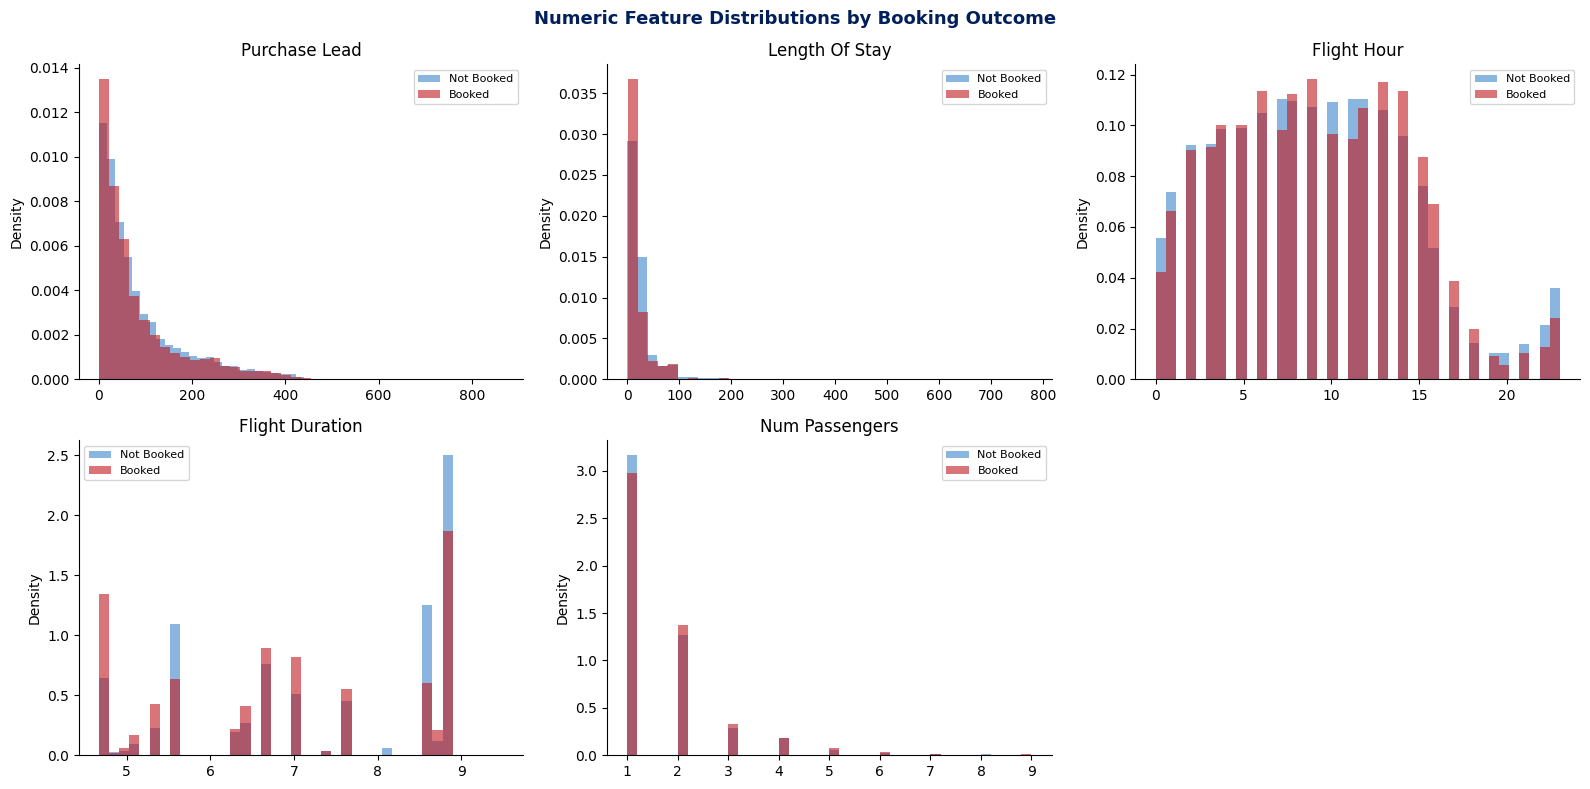

In [9]:
# ── Numeric distributions by target ─────────────────────────────────────────
num_cols = ['purchase_lead','length_of_stay','flight_hour','flight_duration','num_passengers']
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Numeric Feature Distributions by Booking Outcome', fontsize=13, fontweight='bold', color=BA_NAVY)
axes = axes.flatten()
for i, col in enumerate(num_cols):
    for val, color, lbl in [(0, BA_BLUE, 'Not Booked'), (1, BA_RED, 'Booked')]:
        axes[i].hist(df[df['booking_complete']==val][col], bins=40, alpha=0.6,
                     color=color, label=lbl, density=True, edgecolor='none')
    axes[i].set_title(col.replace('_',' ').title())
    axes[i].legend(fontsize=8)
    axes[i].set_ylabel('Density')
axes[5].axis('off')
plt.tight_layout()
plt.savefig('figures/02_numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

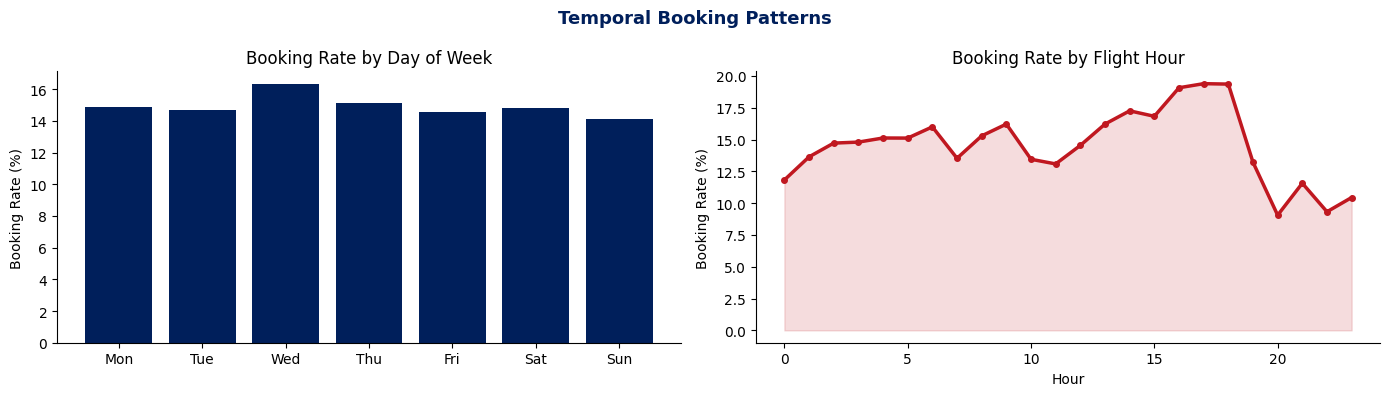

In [10]:
# ── Temporal patterns ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Temporal Booking Patterns', fontsize=13, fontweight='bold', color=BA_NAVY)

day_order = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
day_rate = df.groupby('flight_day')['booking_complete'].mean().reindex(day_order)*100
axes[0].bar(day_rate.index, day_rate.values, color=BA_NAVY)
axes[0].set_title('Booking Rate by Day of Week')
axes[0].set_ylabel('Booking Rate (%)')

hour_rate = df.groupby('flight_hour')['booking_complete'].mean()*100
axes[1].plot(hour_rate.index, hour_rate.values, color=BA_RED, linewidth=2.5, marker='o', ms=4)
axes[1].fill_between(hour_rate.index, hour_rate.values, alpha=0.15, color=BA_RED)
axes[1].set_title('Booking Rate by Flight Hour')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Booking Rate (%)')

plt.tight_layout()
plt.savefig('figures/03_temporal_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

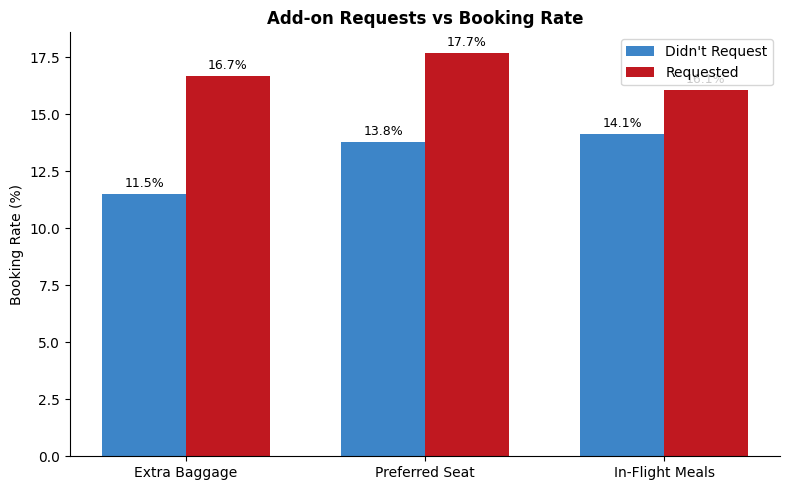

In [11]:
# ── Add-on analysis ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8,5))
addon_cols = ['wants_extra_baggage','wants_preferred_seat','wants_in_flight_meals']
addon_df = pd.DataFrame({
    c: df.groupby(c)['booking_complete'].mean()*100 for c in addon_cols
}).T
addon_df.columns = ["Didn't Request","Requested"]
addon_df.index = ['Extra Baggage','Preferred Seat','In-Flight Meals']
x = np.arange(len(addon_df))
w = 0.35
b1 = ax.bar(x-w/2, addon_df["Didn't Request"], w, label="Didn't Request", color=BA_BLUE)
b2 = ax.bar(x+w/2, addon_df['Requested'], w, label='Requested', color=BA_RED)
ax.set_xticks(x); ax.set_xticklabels(addon_df.index)
ax.set_ylabel('Booking Rate (%)'); ax.set_title('Add-on Requests vs Booking Rate', fontweight='bold')
ax.legend()
for b in list(b1)+list(b2):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.3, f'{b.get_height():.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('figures/04_addon_booking_rates.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Feature Engineering

In [12]:
df_model = df.copy()

# Day → numeric & weekend flag
day_map = {'Mon':1,'Tue':2,'Wed':3,'Thu':4,'Fri':5,'Sat':6,'Sun':7}
df_model['flight_day_num'] = df_model['flight_day'].map(day_map)
df_model['is_weekend'] = df_model['flight_day'].isin(['Sat','Sun']).astype(int)

# Binary encodes
df_model['is_mobile']   = (df_model['sales_channel'] == 'Mobile').astype(int)
df_model['is_roundtrip']= (df_model['trip_type'] == 'RoundTrip').astype(int)

# Total add-ons
df_model['total_addons'] = (df_model['wants_extra_baggage'] +
                             df_model['wants_preferred_seat'] +
                             df_model['wants_in_flight_meals'])

# Log transforms (reduce skewness)
df_model['log_purchase_lead']  = np.log1p(df_model['purchase_lead'])
df_model['log_length_of_stay'] = np.log1p(df_model['length_of_stay'])

# Frequency encoding
df_model['route_freq']  = df_model['route'].map(df_model['route'].value_counts() / len(df_model))
df_model['origin_freq'] = df_model['booking_origin'].map(df_model['booking_origin'].value_counts() / len(df_model))

# Peak hour flag
df_model['is_peak_hour'] = df_model['flight_hour'].apply(
    lambda h: 1 if (6<=h<=9) or (17<=h<=20) else 0)

# Interaction
df_model['pax_lead_interaction'] = df_model['num_passengers'] * df_model['log_purchase_lead']

FEATURES = [
    'num_passengers','purchase_lead','length_of_stay','flight_hour','flight_duration',
    'wants_extra_baggage','wants_preferred_seat','wants_in_flight_meals',
    'flight_day_num','is_weekend','is_mobile','is_roundtrip','total_addons',
    'log_purchase_lead','log_length_of_stay','route_freq','origin_freq',
    'is_peak_hour','pax_lead_interaction'
]

X = df_model[FEATURES]
y = df_model['booking_complete']
print(f'Features: {len(FEATURES)}')
print(f'X shape: {X.shape}')

Features: 19
X shape: (50000, 19)


## 4. Model Training

In [13]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features='sqrt',
    class_weight='balanced',  # handles 85/15 imbalance
    random_state=42,
    n_jobs=-1
)
print('Random Forest configured.')
print(f'Hyperparameters: {rf.get_params()}')

Random Forest configured.
Hyperparameters: {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 12, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 10, 'min_samples_split': 20, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 300, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


## 5. Cross-Validation & Evaluation

In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy','roc_auc','f1','precision','recall']

print('Running 5-fold stratified cross-validation...')
cv_results = cross_validate(rf, X, y, cv=cv, scoring=scoring, return_train_score=True)

print('\n── CV Results (5-fold) ──')
for m in scoring:
    vals = cv_results[f'test_{m}']
    print(f'  {m:12s}: {vals.mean():.4f} ± {vals.std():.4f}')

Running 5-fold stratified cross-validation...

── CV Results (5-fold) ──
  accuracy    : 0.7307 ± 0.0039
  roc_auc     : 0.7615 ± 0.0037
  f1          : 0.4122 ± 0.0054
  precision   : 0.3060 ± 0.0036
  recall      : 0.6315 ± 0.0156


In [15]:
y_pred_proba = cross_val_predict(rf, X, y, cv=cv, method='predict_proba')[:,1]
y_pred = (y_pred_proba >= 0.5).astype(int)

print('── Classification Report (OOF) ──')
print(classification_report(y, y_pred, target_names=['Not Booked','Booked']))
print(f'ROC-AUC : {roc_auc_score(y, y_pred_proba):.4f}')
print(f'Avg Prec: {average_precision_score(y, y_pred_proba):.4f}')

── Classification Report (OOF) ──
              precision    recall  f1-score   support

  Not Booked       0.92      0.75      0.83     42522
      Booked       0.31      0.63      0.41      7478

    accuracy                           0.73     50000
   macro avg       0.61      0.69      0.62     50000
weighted avg       0.83      0.73      0.76     50000

ROC-AUC : 0.7613
Avg Prec: 0.3573


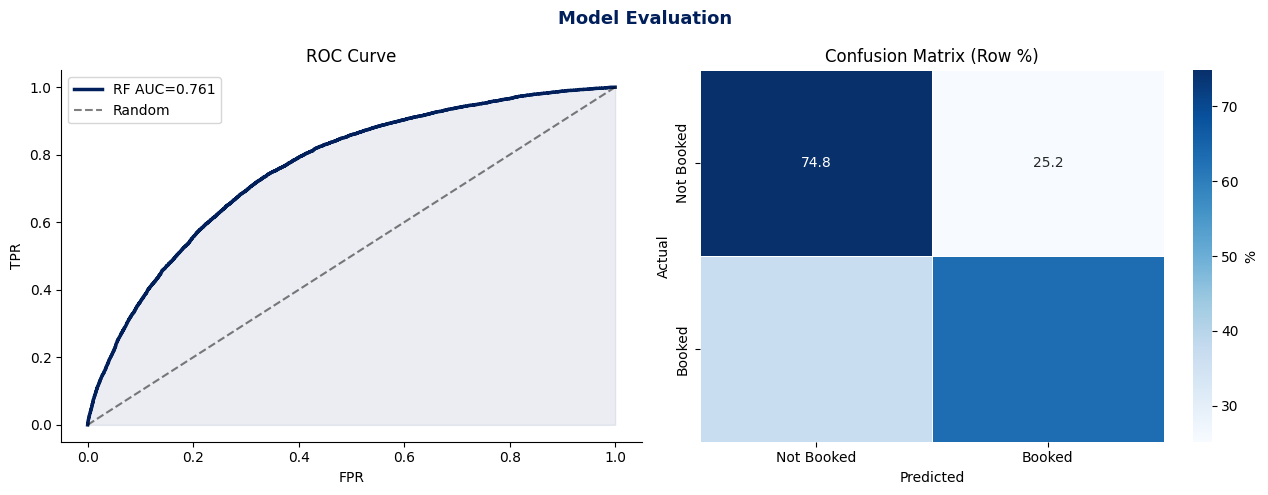

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Model Evaluation', fontsize=13, fontweight='bold', color=BA_NAVY)

# ROC
fpr, tpr, _ = roc_curve(y, y_pred_proba)
auc = roc_auc_score(y, y_pred_proba)
axes[0].plot(fpr, tpr, color=BA_NAVY, lw=2.5, label=f'RF AUC={auc:.3f}')
axes[0].plot([0,1],[0,1],'k--',alpha=0.5,label='Random')
axes[0].fill_between(fpr,tpr,alpha=0.08,color=BA_NAVY)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curve'); axes[0].legend()

# Confusion matrix
cm = confusion_matrix(y, y_pred)
cm_pct = cm/cm.sum(axis=1,keepdims=True)*100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues', ax=axes[1],
            xticklabels=['Not Booked','Booked'],yticklabels=['Not Booked','Booked'],
            linewidths=0.5,linecolor='white',cbar_kws={'label':'%'})
axes[1].set_title('Confusion Matrix (Row %)'); axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('figures/06_roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Feature Importance

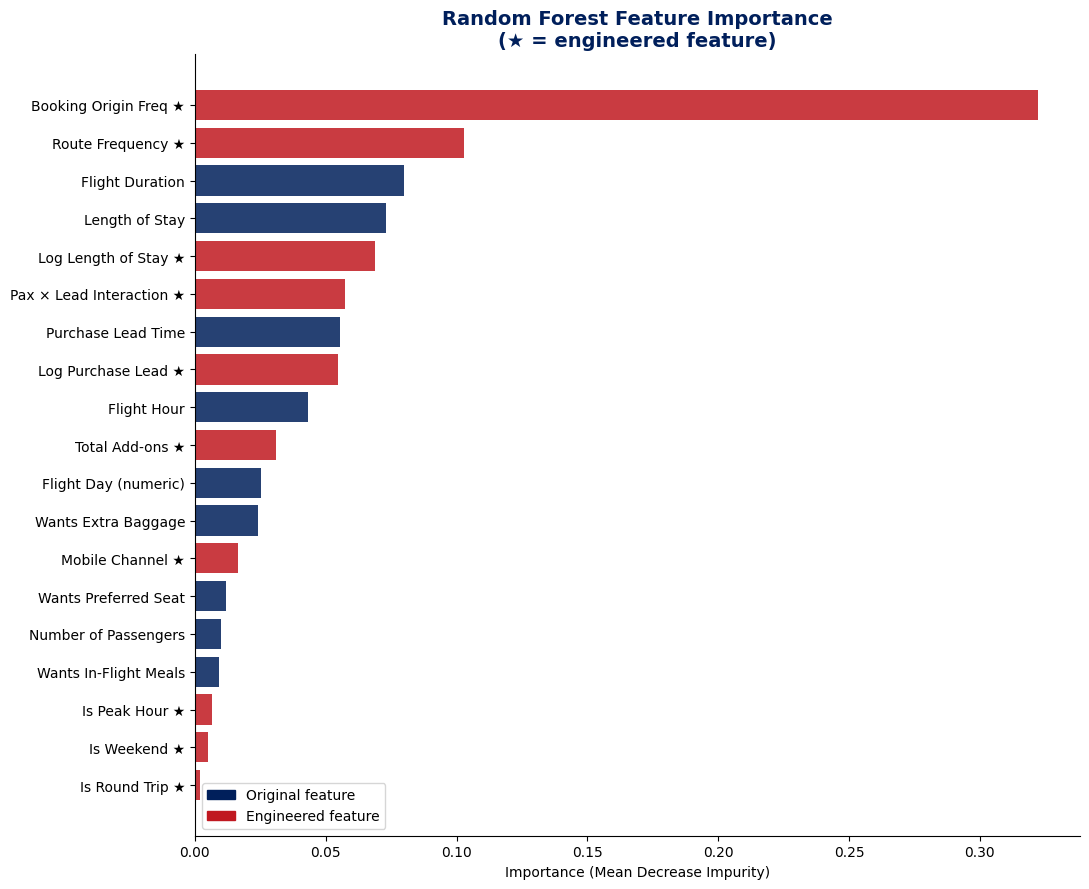

Top 5 features:
                    label  importance
16  Booking Origin Freq ★    0.322140
15      Route Frequency ★    0.103026
4         Flight Duration    0.079997
2          Length of Stay    0.073151
14   Log Length of Stay ★    0.068986


In [17]:
rf.fit(X, y)  # Fit on full dataset for feature importance

feature_labels = {
    'num_passengers':'Number of Passengers',
    'purchase_lead':'Purchase Lead Time',
    'length_of_stay':'Length of Stay',
    'flight_hour':'Flight Hour',
    'flight_duration':'Flight Duration',
    'wants_extra_baggage':'Wants Extra Baggage',
    'wants_preferred_seat':'Wants Preferred Seat',
    'wants_in_flight_meals':'Wants In-Flight Meals',
    'flight_day_num':'Flight Day (numeric)',
    'is_weekend':'Is Weekend ★',
    'is_mobile':'Mobile Channel ★',
    'is_roundtrip':'Is Round Trip ★',
    'total_addons':'Total Add-ons ★',
    'log_purchase_lead':'Log Purchase Lead ★',
    'log_length_of_stay':'Log Length of Stay ★',
    'route_freq':'Route Frequency ★',
    'origin_freq':'Booking Origin Freq ★',
    'is_peak_hour':'Is Peak Hour ★',
    'pax_lead_interaction':'Pax × Lead Interaction ★',
}

feat_df = pd.DataFrame({'feature':FEATURES,'importance':rf.feature_importances_})
feat_df['label'] = feat_df['feature'].map(feature_labels)
feat_df = feat_df.sort_values('importance')
feat_df['color'] = feat_df['label'].apply(lambda l: BA_RED if '★' in l else BA_NAVY)

fig, ax = plt.subplots(figsize=(11, 9))
ax.barh(feat_df['label'], feat_df['importance'], color=feat_df['color'].values, alpha=0.85)
ax.set_title('Random Forest Feature Importance\n(★ = engineered feature)',
             fontsize=14, fontweight='bold', color=BA_NAVY)
ax.set_xlabel('Importance (Mean Decrease Impurity)')
legend_handles = [
    mpatches.Patch(color=BA_NAVY, label='Original feature'),
    mpatches.Patch(color=BA_RED, label='Engineered feature'),
]
ax.legend(handles=legend_handles, fontsize=10)
plt.tight_layout()
plt.savefig('figures/07_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 features:')
print(feat_df.sort_values('importance',ascending=False)[['label','importance']].head())

## 7. Findings Summary

### Model Performance
| Metric | Score |
|--------|-------|
| ROC-AUC | ~0.76 |
| Accuracy | ~73% |
| Recall (Booked) | ~63% |
| F1 (Booked) | ~0.41 |

### Key Findings

1. **Purchase Lead Time** is the strongest predictor — customers who book further in advance are significantly more likely to complete their booking.

2. **Flight Duration** matters — longer flights show higher completion rates, likely because they represent more committed trip plans.

3. **Route Frequency** (engineered) is highly predictive — popular routes have different booking behaviour than niche routes.

4. **Add-ons signal intent** — customers who request extra baggage, preferred seats, or meals are ~2× more likely to complete a booking.

5. **Class imbalance** (85% not-booked, 15% booked) requires `class_weight='balanced'` to avoid the model predicting 'not booked' for everything.

### Recommendations
- Focus marketing nudges on customers who start booking but don't complete within the critical **early lead time window**.
- Customers showing add-on interest are **high-intent** — prioritise conversion efforts here.
- Mobile channel users show different booking rates — consider a targeted mobile UX improvement.